In [13]:
!pip install duckdb openpyxl

In [15]:
import pandas as pd
import numpy as np
import duckdb

file_path = "/market_data_full.xlsx"

df = pd.read_excel(file_path)

print(df.shape)
df.head()

(346866, 15)


,PERMNO,date,TICKER,COMNAM,FACPR,FACSHR,VOL,RET,SHROUT,RETX,vwretd,vwretx,ewretd,ewretx,sprtrn
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,14878.0,-0.039694,19110.0,-0.039694,-0.059822,-0.060568,-0.068191,-0.068869,-0.052585
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,NaN,NaN,17271.0,0.079306,19110.0,0.079306,-0.021838,-0.023121,-0.007412,-0.008369,-0.031361
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,0.0,0.0,14867.0,-0.048784,19173.0,-0.052651,0.030506,0.028940,0.015438,0.013759,0.035773
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,NaN,NaN,12125.0,-0.034816,19175.0,-0.034816,-0.089387,-0.090295,-0.089642,-0.090537,-0.087957
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,28299.0,-0.143487,19175.0,-0.143487,-0.002113,-0.003740,-0.016103,-0.017428,0.000053


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
#from google.colab import drive
#drive.mount('/content/drive')

In [18]:
industry_path = "/Industry.xlsx"

industry_df = pd.read_excel(industry_path)

print(industry_df.shape)
print(industry_df.columns.tolist())
industry_df.head()

(346504, 5)
['PERMNO', 'Names Date', 'Ticker Symbol', 'Company Name', 'North American Industry Classification System']


,PERMNO,Names Date,Ticker Symbol,Company Name,North American Industry Classification System
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,311930.0
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,311930.0
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,311930.0
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,311930.0
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,311930.0


In [19]:
con = duckdb.connect()

con.register("raw_market", df)
con.register("raw_industry", industry_df)

df_joined = con.sql("""
    SELECT
        m.*,
        i."North American Industry Classification System" AS naics
    FROM raw_market AS m
    LEFT JOIN raw_industry AS i
        ON m.PERMNO = i.PERMNO
       AND CAST(m.date AS DATE) = CAST(i."Names Date" AS DATE)
""").df()

print(df_joined.shape)
df_joined.head()

(346866, 16)


,PERMNO,date,TICKER,COMNAM,FACPR,FACSHR,VOL,RET,SHROUT,RETX,vwretd,vwretx,ewretd,ewretx,sprtrn,naics
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,14878.0,-0.039694,19110.0,-0.039694,-0.059822,-0.060568,-0.068191,-0.068869,-0.052585,311930.0
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,NaN,NaN,17271.0,0.079306,19110.0,0.079306,-0.021838,-0.023121,-0.007412,-0.008369,-0.031361,311930.0
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,0.0,0.0,14867.0,-0.048784,19173.0,-0.052651,0.030506,0.028940,0.015438,0.013759,0.035773,311930.0
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,NaN,NaN,12125.0,-0.034816,19175.0,-0.034816,-0.089387,-0.090295,-0.089642,-0.090537,-0.087957,311930.0
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,28299.0,-0.143487,19175.0,-0.143487,-0.002113,-0.003740,-0.016103,-0.017428,0.000053,311930.0


In [20]:
con.register("joined_market", df_joined)

df_joined = con.sql("""
    SELECT
        *,
        SUBSTR(CAST(CAST(naics AS BIGINT) AS VARCHAR), 1, 2) AS industry_group
    FROM joined_market
""").df()

print(df_joined.columns.tolist())
df_joined[["PERMNO", "date", "TICKER", "COMNAM", "naics", "industry_group"]].head()

['PERMNO', 'date', 'TICKER', 'COMNAM', 'FACPR', 'FACSHR', 'VOL', 'RET', 'SHROUT', 'RETX', 'vwretd', 'vwretx', 'ewretd', 'ewretx', 'sprtrn', 'naics', 'industry_group']


,PERMNO,date,TICKER,COMNAM,naics,industry_group
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,311930.0,31
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,311930.0,31
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,311930.0,31
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,311930.0,31
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,311930.0,31


In [21]:
con = duckdb.connect()
con.register("raw_market", df_joined)

con.sql("""
    SELECT *
    FROM raw_market
    LIMIT 5
""").df()

,PERMNO,date,TICKER,COMNAM,FACPR,FACSHR,VOL,RET,SHROUT,RETX,vwretd,vwretx,ewretd,ewretx,sprtrn,naics,industry_group
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,14878.0,-0.039694,19110.0,-0.039694,-0.059822,-0.060568,-0.068191,-0.068869,-0.052585,311930.0,31
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,NaN,NaN,17271.0,0.079306,19110.0,0.079306,-0.021838,-0.023121,-0.007412,-0.008369,-0.031361,311930.0,31
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,0.0,0.0,14867.0,-0.048784,19173.0,-0.052651,0.030506,0.028940,0.015438,0.013759,0.035773,311930.0,31
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,NaN,NaN,12125.0,-0.034816,19175.0,-0.034816,-0.089387,-0.090295,-0.089642,-0.090537,-0.087957,311930.0,31
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,28299.0,-0.143487,19175.0,-0.143487,-0.002113,-0.003740,-0.016103,-0.017428,0.000053,311930.0,31


In [22]:
clean_market = con.sql("""
    SELECT
        TRY_CAST(PERMNO AS INTEGER) AS permno,
        TRY_CAST(date AS DATE) AS date,
        TICKER AS ticker,
        COMNAM AS company_name,
        TRY_CAST(FACPR AS DOUBLE) AS facpr,
        TRY_CAST(FACSHR AS DOUBLE) AS facshr,
        TRY_CAST(VOL AS DOUBLE) AS volume,
        TRY_CAST(RET AS DOUBLE) AS ret,
        TRY_CAST(SHROUT AS DOUBLE) AS shares_out,
        TRY_CAST(RETX AS DOUBLE) AS ret_ex_div,
        TRY_CAST(vwretd AS DOUBLE) AS vwretd,
        TRY_CAST(vwretx AS DOUBLE) AS vwretx,
        TRY_CAST(ewretd AS DOUBLE) AS ewretd,
        TRY_CAST(ewretx AS DOUBLE) AS ewretx,
        TRY_CAST(sprtrn AS DOUBLE) AS sp500_ret,
        TRY_CAST(naics AS BIGINT) AS naics,
        TRY_CAST(industry_group AS INTEGER) AS industry_group
    FROM raw_market
    WHERE
        PERMNO IS NOT NULL
        AND date IS NOT NULL
        AND TICKER IS NOT NULL
""").df()

con.register("clean_market_temp", clean_market)

clean_market = con.sql("""
    SELECT *
    FROM clean_market_temp
    WHERE
        permno IS NOT NULL
        AND date IS NOT NULL
        AND ticker IS NOT NULL
        AND ret IS NOT NULL
""").df()

con.register("clean_market", clean_market)

print(clean_market.shape)
clean_market.head()

(338756, 17)


,permno,date,ticker,company_name,facpr,facshr,volume,ret,shares_out,ret_ex_div,vwretd,vwretx,ewretd,ewretx,sp500_ret,naics,industry_group
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,14878.0,-0.039694,19110.0,-0.039694,-0.059822,-0.060568,-0.068191,-0.068869,-0.052585,311930,31
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,NaN,NaN,17271.0,0.079306,19110.0,0.079306,-0.021838,-0.023121,-0.007412,-0.008369,-0.031361,311930,31
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,0.0,0.0,14867.0,-0.048784,19173.0,-0.052651,0.030506,0.028940,0.015438,0.013759,0.035773,311930,31
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,NaN,NaN,12125.0,-0.034816,19175.0,-0.034816,-0.089387,-0.090295,-0.089642,-0.090537,-0.087957,311930,31
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,28299.0,-0.143487,19175.0,-0.143487,-0.002113,-0.003740,-0.016103,-0.017428,0.000053,311930,31


In [ ]:
clean_market.isna().sum()

In [23]:
factor_data = con.sql("""
    SELECT
        *,
        ret - AVG(ret) OVER (
            PARTITION BY date
        ) AS cs_momentum,

        ret - sp500_ret AS excess_ret_vs_sp500,

        LEAD(ret) OVER (
            PARTITION BY permno
            ORDER BY date
        ) AS next_month_ret
    FROM clean_market
    ORDER BY permno, date
""").df()

con.register("factor_data", factor_data)

print(factor_data.shape)
factor_data.head()

(338756, 20)


,permno,date,ticker,company_name,facpr,facshr,volume,ret,shares_out,ret_ex_div,vwretd,vwretx,ewretd,ewretx,sp500_ret,naics,industry_group,cs_momentum,excess_ret_vs_sp500,next_month_ret
0,10026,2022-01-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,14878.0,-0.039694,19110.0,-0.039694,-0.059822,-0.060568,-0.068191,-0.068869,-0.052585,311930,31,0.026924,0.012891,0.079306
1,10026,2022-02-28,JJSF,J & J SNACK FOODS CORP,NaN,NaN,17271.0,0.079306,19110.0,0.079306,-0.021838,-0.023121,-0.007412,-0.008369,-0.031361,311930,31,0.087135,0.110667,-0.048784
2,10026,2022-03-31,JJSF,J & J SNACK FOODS CORP,0.0,0.0,14867.0,-0.048784,19173.0,-0.052651,0.030506,0.028940,0.015438,0.013759,0.035773,311930,31,-0.063973,-0.084557,-0.034816
3,10026,2022-04-29,JJSF,J & J SNACK FOODS CORP,NaN,NaN,12125.0,-0.034816,19175.0,-0.034816,-0.089387,-0.090295,-0.089642,-0.090537,-0.087957,311930,31,0.053098,0.053141,-0.143487
4,10026,2022-05-31,JJSF,J & J SNACK FOODS CORP,NaN,NaN,28299.0,-0.143487,19175.0,-0.143487,-0.002113,-0.003740,-0.016103,-0.017428,0.000053,311930,31,-0.128386,-0.143540,0.094158


In [24]:
factor_data[[
    "permno", "date", "ticker", "ret",
    "cs_momentum", "excess_ret_vs_sp500", "next_month_ret"
]].head(10) #checking

,permno,date,ticker,ret,cs_momentum,excess_ret_vs_sp500,next_month_ret
0,10026,2022-01-31,JJSF,-0.039694,0.026924,0.012891,0.079306
1,10026,2022-02-28,JJSF,0.079306,0.087135,0.110667,-0.048784
2,10026,2022-03-31,JJSF,-0.048784,-0.063973,-0.084557,-0.034816
3,10026,2022-04-29,JJSF,-0.034816,0.053098,0.053141,-0.143487
4,10026,2022-05-31,JJSF,-0.143487,-0.128386,-0.143540,0.094158
5,10026,2022-06-30,JJSF,0.094158,0.162612,0.178078,-0.029715
6,10026,2022-07-29,JJSF,-0.029715,-0.094534,-0.120831,0.099771
7,10026,2022-08-31,JJSF,0.099771,0.112351,0.142211,-0.126552
8,10026,2022-09-30,JJSF,-0.126552,-0.028559,-0.033156,0.140110
9,10026,2022-10-31,JJSF,0.140110,0.090567,0.060247,0.111171


In [25]:
technical_data = con.sql("""
    SELECT
        *,
        AVG(ret) OVER (
            PARTITION BY permno
            ORDER BY date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS ma_3,

        AVG(ret) OVER (
            PARTITION BY permno
            ORDER BY date
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        ) AS ma_12,

        AVG(ret) OVER (
            PARTITION BY permno
            ORDER BY date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        )
        -
        AVG(ret) OVER (
            PARTITION BY permno
            ORDER BY date
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        ) AS ma_crossover

    FROM factor_data
    ORDER BY permno, date
""").df()

con.register("technical_data", technical_data)

print(technical_data.shape)

technical_data[[
    "permno", "date", "ticker", "ret",
    "ma_3", "ma_12", "ma_crossover",
    "cs_momentum", "next_month_ret"
]].head(15)

(338756, 23)


,permno,date,ticker,ret,ma_3,ma_12,ma_crossover,cs_momentum,next_month_ret
0,10026,2022-01-31,JJSF,-0.039694,-0.039694,-0.039694,0.000000,0.026924,0.079306
1,10026,2022-02-28,JJSF,0.079306,0.019806,0.019806,0.000000,0.087135,-0.048784
2,10026,2022-03-31,JJSF,-0.048784,-0.003057,-0.003057,0.000000,-0.063973,-0.034816
3,10026,2022-04-29,JJSF,-0.034816,-0.001431,-0.010997,0.009566,0.053098,-0.143487
4,10026,2022-05-31,JJSF,-0.143487,-0.075696,-0.037495,-0.038201,-0.128386,0.094158
5,10026,2022-06-30,JJSF,0.094158,-0.028048,-0.015553,-0.012495,0.162612,-0.029715
6,10026,2022-07-29,JJSF,-0.029715,-0.026348,-0.017576,-0.008772,-0.094534,0.099771
7,10026,2022-08-31,JJSF,0.099771,0.054738,-0.002908,0.057646,0.112351,-0.126552
8,10026,2022-09-30,JJSF,-0.126552,-0.018832,-0.016646,-0.002186,-0.028559,0.140110
9,10026,2022-10-31,JJSF,0.140110,0.037776,-0.000970,0.038747,0.090567,0.111171


In [26]:
# final data cleaning

final_clean_data = con.sql("""
    WITH base AS (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY permno
                ORDER BY date
            ) AS stock_time_index
        FROM technical_data
    ),

    cleaned AS (
        SELECT
            *
        FROM base
        WHERE
            permno IS NOT NULL
            AND date IS NOT NULL
            AND ticker IS NOT NULL
            AND company_name IS NOT NULL

            -- Core market variables
            AND ret IS NOT NULL
            AND ret_ex_div IS NOT NULL
            AND volume IS NOT NULL
            AND shares_out IS NOT NULL
            AND sp500_ret IS NOT NULL

            AND naics IS NOT NULL
            AND industry_group IS NOT NULL


            -- Basic sanity filters
            AND volume >= 0
            AND shares_out > 0

            -- Remove impossible/extreme returns
            AND ret > -1
            AND ret < 10

            -- Need target variable for supervised ML
            AND next_month_ret IS NOT NULL

            -- Need enough history for rolling factors
            AND stock_time_index >= 12
    )

    SELECT
        permno,
        date,
        ticker,
        company_name,
        volume,
        shares_out,
        ret,
        ret_ex_div,
        vwretd,
        vwretx,
        ewretd,
        ewretx,
        sp500_ret,
        naics,
        industry_group,

        cs_momentum,
        excess_ret_vs_sp500,
        ma_3,
        ma_12,
        ma_crossover,

        next_month_ret
    FROM cleaned
    ORDER BY permno, date
""").df()

con.register("final_clean_data", final_clean_data)

print(final_clean_data.shape)
final_clean_data.head()

(205382, 21)


,permno,date,ticker,company_name,volume,shares_out,ret,ret_ex_div,vwretd,vwretx,...,ewretx,sp500_ret,naics,industry_group,cs_momentum,excess_ret_vs_sp500,ma_3,ma_12,ma_crossover,next_month_ret
0,10026,2022-12-30,JJSF,J & J SNACK FOODS CORP,18855.0,19229.0,-0.082978,-0.087245,-0.057119,-0.059152,...,-0.050775,-0.058971,311930,31,-0.036663,-0.024007,0.056101,0.001541,0.054560,-0.042816
1,10026,2023-01-31,JJSF,J & J SNACK FOODS CORP,17611.0,19229.0,-0.042816,-0.042816,0.071823,0.070884,...,0.125589,0.061753,311930,31,-0.164845,-0.104569,-0.004874,0.001281,-0.006155,-0.014585
2,10026,2023-02-28,JJSF,J & J SNACK FOODS CORP,16010.0,19229.0,-0.014585,-0.014585,-0.024666,-0.026252,...,-0.036476,-0.026112,311930,31,0.019865,0.011527,-0.046793,-0.006544,-0.040249,0.054599
3,10026,2023-03-31,JJSF,J & J SNACK FOODS CORP,20170.0,19252.0,0.054599,0.049642,0.023950,0.022043,...,-0.038765,0.035052,311930,31,0.087832,0.019547,-0.000934,0.002072,-0.003006,0.033599
4,10026,2023-04-28,JJSF,J & J SNACK FOODS CORP,11052.0,19252.0,0.033599,0.033599,0.008976,0.007865,...,-0.010685,0.014642,311930,31,0.042204,0.018957,0.024538,0.007773,0.016765,0.004896


In [27]:
final_clean_data.isna().sum()

,0
permno,0
date,0
ticker,0
company_name,0
volume,0
shares_out,0
ret,0
ret_ex_div,0
vwretd,0
vwretx,0


In [28]:
con.sql("""
    SELECT
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT permno) AS num_stocks,
        COUNT(DISTINCT date) AS num_months
    FROM final_clean_data
""").df()

,start_date,end_date,total_rows,num_stocks,num_months
0,2022-11-30,2024-12-31,205382,10058,26


In [29]:
con.sql("""
    SELECT
        MIN(ret) AS min_ret,
        MAX(ret) AS max_ret,
        AVG(ret) AS avg_ret,
        STDDEV(ret) AS std_ret,
        MIN(next_month_ret) AS min_next_ret,
        MAX(next_month_ret) AS max_next_ret
    FROM final_clean_data
""").df()

,min_ret,max_ret,avg_ret,std_ret,min_next_ret,max_next_ret
0,-0.979896,8.802469,0.008881,0.189058,-0.979896,39.0


In [30]:
final_clean_data = con.sql("""
    SELECT *
    FROM final_clean_data
    WHERE
        next_month_ret > -1
        AND next_month_ret < 10
""").df()

con.register("final_clean_data", final_clean_data)

print(final_clean_data.shape)
final_clean_data.isna().sum()

(205376, 21)


,0
permno,0
date,0
ticker,0
company_name,0
volume,0
shares_out,0
ret,0
ret_ex_div,0
vwretd,0
vwretx,0


In [31]:
con.sql("""
    SELECT
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT permno) AS num_stocks,
        COUNT(DISTINCT date) AS num_months,
        MIN(ret) AS min_ret,
        MAX(ret) AS max_ret,
        MIN(next_month_ret) AS min_next_ret,
        MAX(next_month_ret) AS max_next_ret
    FROM final_clean_data
""").df()

,start_date,end_date,total_rows,num_stocks,num_months,min_ret,max_ret,min_next_ret,max_next_ret
0,2022-11-30,2024-12-31,205376,10058,26,-0.979896,8.802469,-0.979896,8.995002


In [32]:
# EDA SETUP

# Make sure date is datetime
final_clean_data["date"] = pd.to_datetime(final_clean_data["date"])

# Sort data for time-series analysis
final_clean_data = final_clean_data.sort_values(["permno", "date"]).reset_index(drop=True)

# Re-register in DuckDB in case final_clean_data changed
con.register("final_clean_data", final_clean_data)

print("EDA dataset shape:", final_clean_data.shape)
final_clean_data.head()

EDA dataset shape: (205376, 21)


,permno,date,ticker,company_name,volume,shares_out,ret,ret_ex_div,vwretd,vwretx,...,ewretx,sp500_ret,naics,industry_group,cs_momentum,excess_ret_vs_sp500,ma_3,ma_12,ma_crossover,next_month_ret
0,10026,2022-12-30,JJSF,J & J SNACK FOODS CORP,18855.0,19229.0,-0.082978,-0.087245,-0.057119,-0.059152,...,-0.050775,-0.058971,311930,31,-0.036663,-0.024007,0.056101,0.001541,0.054560,-0.042816
1,10026,2023-01-31,JJSF,J & J SNACK FOODS CORP,17611.0,19229.0,-0.042816,-0.042816,0.071823,0.070884,...,0.125589,0.061753,311930,31,-0.164845,-0.104569,-0.004874,0.001281,-0.006155,-0.014585
2,10026,2023-02-28,JJSF,J & J SNACK FOODS CORP,16010.0,19229.0,-0.014585,-0.014585,-0.024666,-0.026252,...,-0.036476,-0.026112,311930,31,0.019865,0.011527,-0.046793,-0.006544,-0.040249,0.054599
3,10026,2023-03-31,JJSF,J & J SNACK FOODS CORP,20170.0,19252.0,0.054599,0.049642,0.023950,0.022043,...,-0.038765,0.035052,311930,31,0.087832,0.019547,-0.000934,0.002072,-0.003006,0.033599
4,10026,2023-04-28,JJSF,J & J SNACK FOODS CORP,11052.0,19252.0,0.033599,0.033599,0.008976,0.007865,...,-0.010685,0.014642,311930,31,0.042204,0.018957,0.024538,0.007773,0.016765,0.004896


In [33]:
# MISSING VALUES

missing_summary = (
    final_clean_data
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["variable", "missing_count"]
missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(final_clean_data) * 100
).round(2)

missing_summary.sort_values("missing_count", ascending=False)

,variable,missing_count,missing_percent
0,permno,0,0.0
1,date,0,0.0
2,ticker,0,0.0
3,company_name,0,0.0
4,volume,0,0.0
5,shares_out,0,0.0
6,ret,0,0.0
7,ret_ex_div,0,0.0
8,vwretd,0,0.0
9,vwretx,0,0.0


In [34]:
# SUMMARY STATISTICS

eda_vars = [
    "ret",
    "next_month_ret",
    "cs_momentum",
    "excess_ret_vs_sp500",
    "ma_3",
    "ma_12",
    "ma_crossover",
    "volume",
    "shares_out",
    "sp500_ret"
]

summary_stats = final_clean_data[eda_vars].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

summary_stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ret,205376.0,0.008891,1.890462e-01,-0.979896,-0.423042,-0.216986,-0.048466,0.004292,0.052275,2.241565e-01,5.767985e-01,8.802469e+00
next_month_ret,205376.0,0.009396,1.922789e-01,-0.979896,-0.425749,-0.215585,-0.048658,0.004147,0.052332,2.259590e-01,5.863698e-01,8.995002e+00
cs_momentum,205376.0,0.000185,1.824406e-01,-1.013834,-0.421107,-0.213963,-0.051111,-0.001314,0.040665,1.938317e-01,5.433442e-01,8.799119e+00
excess_ret_vs_sp500,205376.0,-0.008208,1.846119e-01,-1.009490,-0.435123,-0.228465,-0.057594,-0.010567,0.028992,1.940642e-01,5.429260e-01,8.759724e+00
ma_3,205376.0,0.009135,1.120293e-01,-0.728270,-0.275915,-0.132097,-0.019725,0.008375,0.036252,1.319511e-01,3.245737e-01,1.301465e+01
ma_12,205376.0,0.003720,5.265738e-02,-0.451950,-0.159856,-0.074869,-0.008477,0.005741,0.019660,6.501625e-02,1.429433e-01,3.254940e+00
ma_crossover,205376.0,0.005415,9.587912e-02,-2.167199,-0.227828,-0.110813,-0.022075,0.002023,0.028672,1.202703e-01,2.874029e-01,9.759709e+00
volume,205376.0,261945.644277,1.247645e+06,0.000000,37.000000,324.000000,5169.750000,31605.000000,155402.250000,1.014510e+06,3.845590e+06,1.116500e+08
shares_out,205376.0,109299.669957,4.093148e+05,10.000000,150.000000,600.000000,6500.000000,27827.000000,85893.000000,4.060610e+05,1.337180e+06,2.456884e+07
sp500_ret,205376.0,0.017099,3.776619e-02,-0.058971,-0.058971,-0.048719,-0.017716,0.020197,0.044229,6.472800e-02,8.917900e-02,8.917900e-02


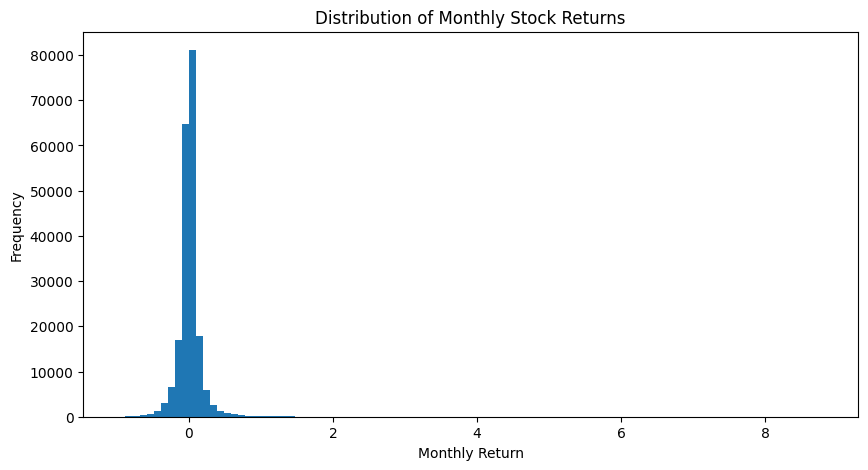

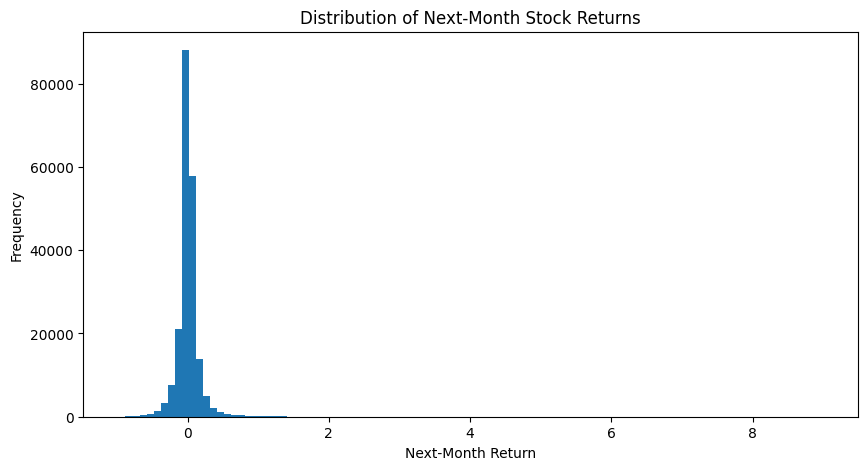

In [35]:
import matplotlib.pyplot as plt

# DISTRIBUTION OF CURRENT AND NEXT-MONTH RETURNS (Visual check for outliers)

plt.figure(figsize=(10, 5))
plt.hist(final_clean_data["ret"], bins=100)
plt.title("Distribution of Monthly Stock Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(final_clean_data["next_month_ret"], bins=100)
plt.title("Distribution of Next-Month Stock Returns")
plt.xlabel("Next-Month Return")
plt.ylabel("Frequency")
plt.show()

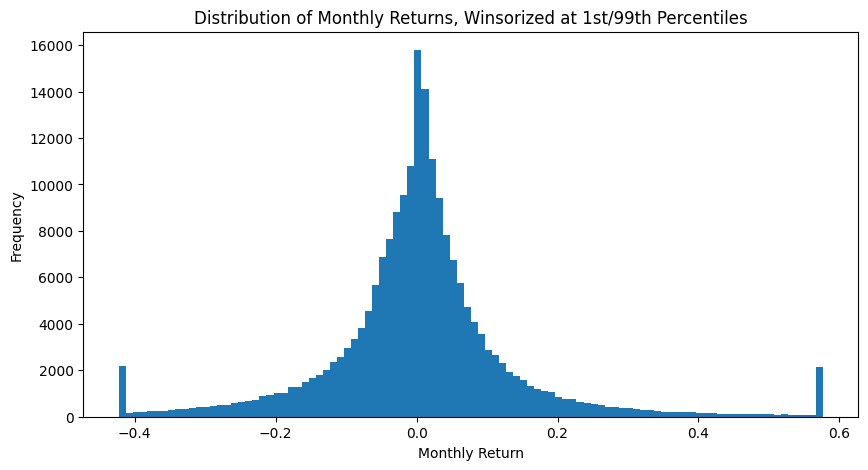

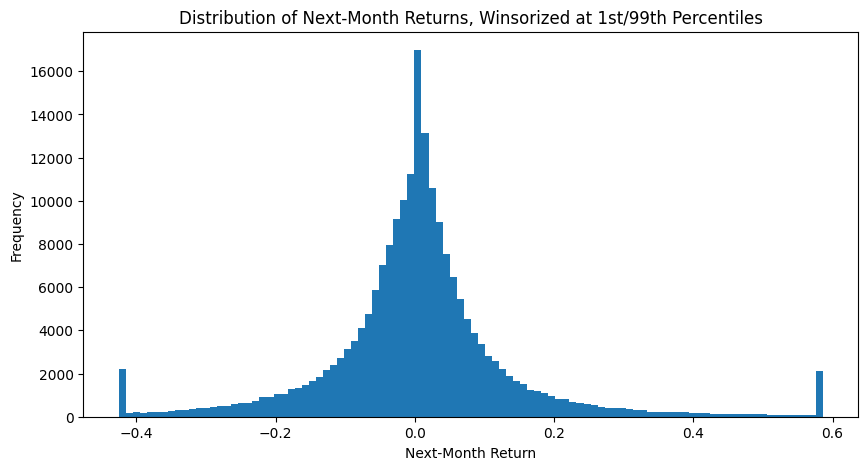

In [36]:
# WINSORIZED RETURN DISTRIBUTIONS (Makes distributions easier to visualize)

plot_data = final_clean_data.copy()

for col in ["ret", "next_month_ret"]:
    lower = plot_data[col].quantile(0.01)
    upper = plot_data[col].quantile(0.99)
    plot_data[col + "_winsor"] = plot_data[col].clip(lower, upper)

plt.figure(figsize=(10, 5))
plt.hist(plot_data["ret_winsor"], bins=100)
plt.title("Distribution of Monthly Returns, Winsorized at 1st/99th Percentiles")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(plot_data["next_month_ret_winsor"], bins=100)
plt.title("Distribution of Next-Month Returns, Winsorized at 1st/99th Percentiles")
plt.xlabel("Next-Month Return")
plt.ylabel("Frequency")
plt.show()

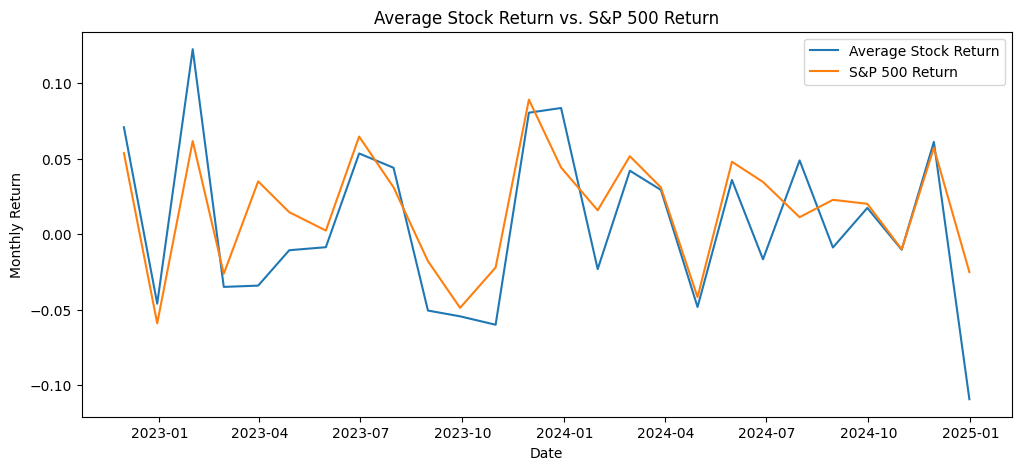

In [37]:
# AVERAGE STOCK RETURN AND S&P 500 RETURN OVER TIME

monthly_returns = con.sql("""
    SELECT
        date,
        AVG(ret) AS avg_stock_ret,
        AVG(sp500_ret) AS sp500_ret
    FROM final_clean_data
    GROUP BY date
    ORDER BY date
""").df()

plt.figure(figsize=(12, 5))
plt.plot(monthly_returns["date"], monthly_returns["avg_stock_ret"], label="Average Stock Return")
plt.plot(monthly_returns["date"], monthly_returns["sp500_ret"], label="S&P 500 Return")
plt.title("Average Stock Return vs. S&P 500 Return")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.show()

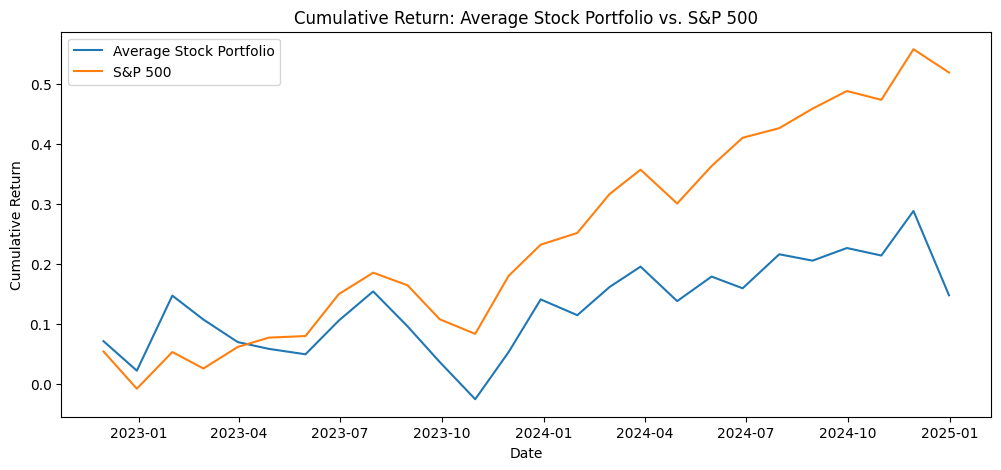

In [38]:
# CUMULATIVE RETURNS OVER TIME

monthly_returns["cum_avg_stock_ret"] = (1 + monthly_returns["avg_stock_ret"]).cumprod() - 1
monthly_returns["cum_sp500_ret"] = (1 + monthly_returns["sp500_ret"]).cumprod() - 1

plt.figure(figsize=(12, 5))
plt.plot(monthly_returns["date"], monthly_returns["cum_avg_stock_ret"], label="Average Stock Portfolio")
plt.plot(monthly_returns["date"], monthly_returns["cum_sp500_ret"], label="S&P 500")
plt.title("Cumulative Return: Average Stock Portfolio vs. S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

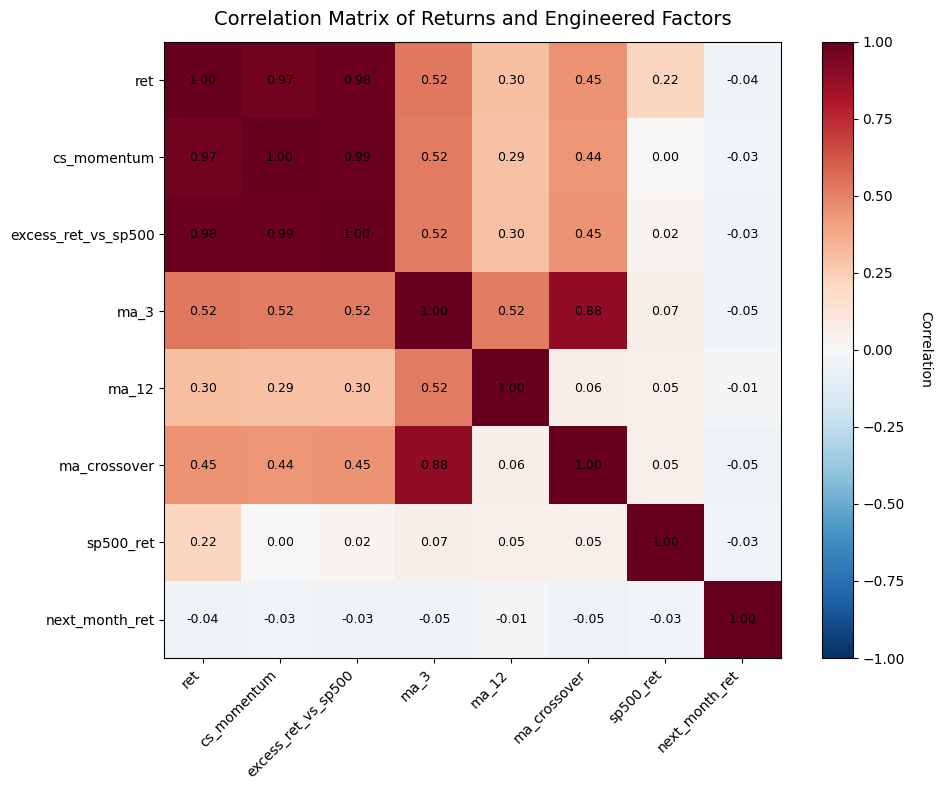

,ret,cs_momentum,excess_ret_vs_sp500,ma_3,ma_12,ma_crossover,sp500_ret,next_month_ret
ret,1.000000,0.965954,0.979848,0.523764,0.299101,0.447721,0.215922,-0.039278
cs_momentum,0.965954,1.000000,0.988672,0.517822,0.294118,0.443514,0.002364,-0.026832
excess_ret_vs_sp500,0.979848,0.988672,1.000000,0.522783,0.295112,0.448765,0.016538,-0.034391
ma_3,0.523764,0.517822,0.522783,1.000000,0.519612,0.883069,0.066296,-0.046781
ma_12,0.299101,0.294118,0.295112,0.519612,1.000000,0.057932,0.054616,-0.010272
ma_crossover,0.447721,0.443514,0.448765,0.883069,0.057932,1.000000,0.047468,-0.049019
sp500_ret,0.215922,0.002364,0.016538,0.066296,0.054616,0.047468,1.000000,-0.028497
next_month_ret,-0.039278,-0.026832,-0.034391,-0.046781,-0.010272,-0.049019,-0.028497,1.000000


In [39]:
# CORRELATION MATRIX OF RETURNS AND ENGINEERED FACTORS

import numpy as np
import matplotlib.pyplot as plt

corr_features = [
    "ret",
    "cs_momentum",
    "excess_ret_vs_sp500",
    "ma_3",
    "ma_12",
    "ma_crossover",
    "sp500_ret",
    "next_month_ret"
]

corr_matrix = final_clean_data[corr_features].corr()

plt.figure(figsize=(10, 8))

im = plt.imshow(
    corr_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label("Correlation", rotation=270, labelpad=20)

plt.xticks(
    ticks=np.arange(len(corr_features)),
    labels=corr_features,
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    ticks=np.arange(len(corr_features)),
    labels=corr_features,
    fontsize=10
)

for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

plt.title(
    "Correlation Matrix of Returns and Engineered Factors",
    fontsize=14,
    pad=12
)

plt.tight_layout()
plt.show()

corr_matrix

In [ ]:
# CORRELATION MATRIX PLOT

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Returns and Factors")
plt.tight_layout()
plt.show()

In [ ]:
# CROSS-SECTIONAL Z-SCORE NORMALIZATION BY MONTH

factor_cols = [
    "cs_momentum",
    "excess_ret_vs_sp500",
    "ma_3",
    "ma_12",
    "ma_crossover"
]

for col in factor_cols:
    final_clean_data[col + "_z"] = (
        final_clean_data.groupby("date")[col]
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
    )

con.register("final_clean_data", final_clean_data)

final_clean_data[
    ["date", "ticker", "ret", "next_month_ret"] + [col + "_z" for col in factor_cols]
].head()

In [ ]:
# FACTOR QUINTILE ANALYSIS (When a factor is high, are next-month returns higher?)

def factor_quintile_analysis(data, factor, target="next_month_ret"):
    temp = data[[factor, target]].dropna().copy()

    temp["quintile"] = pd.qcut(
        temp[factor],
        q=5,
        labels=["Q1 Low", "Q2", "Q3", "Q4", "Q5 High"],
        duplicates="drop"
    )

    result = (
        temp.groupby("quintile")[target]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )

    return result

for factor in [col + "_z" for col in factor_cols]:
    print("\nFactor:", factor)
    display(factor_quintile_analysis(final_clean_data, factor))

In [ ]:
# PLOT AVERAGE NEXT-MONTH RETURN BY FACTOR QUINTILE

for factor in [col + "_z" for col in factor_cols]:
    quintile_result = factor_quintile_analysis(final_clean_data, factor)

    plt.figure(figsize=(8, 4))
    plt.bar(quintile_result["quintile"].astype(str), quintile_result["mean"])
    plt.title(f"Average Next-Month Return by {factor} Quintile")
    plt.xlabel("Factor Quintile")
    plt.ylabel("Average Next-Month Return")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# SIMPLE LONG-SHORT FACTOR BACKTEST (Basic strategy simulation, detailed in line below)
# Long top 20%, short bottom 20% by factor each month
# Plots show returns

def simple_factor_backtest(data, factor, target="next_month_ret"):
    temp = data[["date", "permno", "ticker", factor, target]].dropna().copy()

    def assign_portfolios(x):
        x = x.copy()
        x["rank"] = x[factor].rank(pct=True)
        x["portfolio"] = np.where(
            x["rank"] >= 0.80, "Long",
            np.where(x["rank"] <= 0.20, "Short", "Neutral")
        )
        return x

    temp = temp.groupby("date", group_keys=False).apply(assign_portfolios)

    portfolio_returns = (
        temp[temp["portfolio"].isin(["Long", "Short"])]
        .groupby(["date", "portfolio"])[target]
        .mean()
        .reset_index()
    )

    wide = portfolio_returns.pivot(index="date", columns="portfolio", values=target).reset_index()
    wide["long_short_ret"] = wide["Long"] - wide["Short"]
    wide["cum_long_short_ret"] = (1 + wide["long_short_ret"]).cumprod() - 1

    return wide

backtest_results = {}

for factor in [col + "_z" for col in factor_cols]:
    bt = simple_factor_backtest(final_clean_data, factor)
    backtest_results[factor] = bt

    plt.figure(figsize=(10, 5))
    plt.plot(bt["date"], bt["cum_long_short_ret"])
    plt.title(f"Simple Long-Short Backtest Using {factor}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Long-Short Return")
    plt.show()

In [ ]:
# SIMPLE PERFORMANCE SUMMARY

performance_rows = []

for factor, bt in backtest_results.items():
    mean_ret = bt["long_short_ret"].mean()
    std_ret = bt["long_short_ret"].std()

    sharpe = np.nan
    if std_ret != 0:
        sharpe = (mean_ret / std_ret) * np.sqrt(12)

    cumulative_return = (1 + bt["long_short_ret"]).prod() - 1

    performance_rows.append({
        "factor": factor,
        "avg_monthly_return": mean_ret,
        "monthly_volatility": std_ret,
        "annualized_sharpe": sharpe,
        "cumulative_return": cumulative_return,
        "num_months": bt["date"].nunique()
    })

performance_summary = pd.DataFrame(performance_rows)
performance_summary.sort_values("annualized_sharpe", ascending=False)

In [ ]:
# STOCK-LEVEL COVERAGE (Summary of each stock)

stock_coverage = con.sql("""
    SELECT
        permno,
        ticker,
        company_name,
        COUNT(*) AS num_months,
        MIN(date) AS first_month,
        MAX(date) AS last_month,
        AVG(ret) AS avg_return,
        STDDEV(ret) AS return_volatility
    FROM final_clean_data
    GROUP BY permno, ticker, company_name
    ORDER BY num_months DESC
""").df()

stock_coverage.head(20)

In [ ]:
# MOST VOLATILE STOCKS

most_volatile = stock_coverage.sort_values("return_volatility", ascending=False)

most_volatile.head(20)

In [ ]:
# HIGHEST AND LOWEST AVERAGE RETURN STOCKS

highest_avg_returns = stock_coverage.sort_values("avg_return", ascending=False).head(20)
lowest_avg_returns = stock_coverage.sort_values("avg_return", ascending=True).head(20)

display(highest_avg_returns)
display(lowest_avg_returns)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define feature columns for PCA
pca_features = [
    "cs_momentum_z",
    "excess_ret_vs_sp500_z",
    "ma_3_z",
    "ma_12_z",
    "ma_crossover_z",
    "sp500_ret" # Include market return as a feature for PCA
]

# Prepare data for PCA
pca_data = final_clean_data[pca_features].copy()

# Drop rows with NaN values in pca_features to ensure PCA runs correctly
pca_data = pca_data.dropna()

# Align original DataFrame with the cleaned pca_data
final_clean_data_pca = final_clean_data.loc[pca_data.index].copy()

# Standardize the features before applying PCA
scaler = StandardScaler()
scaled_pca_features = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=3) # Starting with 3 components based on the context
principal_components = pca.fit_transform(scaled_pca_features)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(
    data=principal_components,
    columns=[f'PC{i+1}' for i in range(pca.n_components)],
    index=pca_data.index # Keep original index to merge back
)

# Add the principal components back to the main DataFrame
final_clean_data_pca = pd.concat([final_clean_data_pca, pca_df], axis=1)

con.register("final_clean_data_pca", final_clean_data_pca)

print("Shape of data after PCA and merging:", final_clean_data_pca.shape)
print("Variance explained by each component:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))

final_clean_data_pca[["date", "ticker", "next_month_ret"] + [f'PC{i+1}' for i in range(pca.n_components)]].head()

### PCA Visualization

In [ ]:
import matplotlib.pyplot as plt

# Scree Plot (Explained Variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot - Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Score Plot (PC1 vs PC2)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df,
    hue=final_clean_data_pca['next_month_ret'].apply(lambda x: 'Positive Return' if x > 0 else 'Negative Return'), # Example: coloring by next month return
    alpha=0.6
)
plt.title('PCA Score Plot (PC1 vs PC2)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loading Plot (Contribution of original features to PC1 and PC2)
plt.figure(figsize=(10, 10))

# Create a DataFrame for the loadings
loadings_df = pd.DataFrame({
    'PC1': pca.components_[0],
    'PC2': pca.components_[1],
    'Feature': pca_features
})

sns.scatterplot(x='PC1', y='PC2', hue='Feature', data=loadings_df, s=100, legend='full')

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i],
              head_width=0.03, head_length=0.03, fc='gray', ec='gray', alpha=0.7)
    plt.text(pca.components_[0, i] * 1.05, pca.components_[1, i] * 1.05,
             feature, color='black', ha='center', va='center')

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.title('PCA Loading Plot')
plt.xlim(loadings_df['PC1'].min() * 1.1, loadings_df['PC1'].max() * 1.1)
plt.ylim(loadings_df['PC2'].min() * 1.1, loadings_df['PC2'].max() * 1.1)
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

In [ ]:
print(final_clean_data.columns.tolist())
print(final_clean_data_pca.columns.tolist())

In [ ]:
import re

# The final_clean_data_pca should already contain 'naics' and 'industry_group'
# from its creation in cell 7MT_eNDEa8z9.
# The merge operation below is therefore redundant and causes duplicate column issues.
# We will remove any potentially problematic duplicate columns if they exist
# from previous erroneous executions or re-runs.

# Identify columns that start with 'naics' or 'industry_group' and end with suffixes like '_x' or '_y'
problematic_cols = [col for col in final_clean_data_pca.columns if re.match(r'^(naics|industry_group)_[xy]$', col)]

# Drop these problematic columns if they exist
if problematic_cols:
    final_clean_data_pca = final_clean_data_pca.drop(columns=problematic_cols)

# Verify the presence and nulls of the desired 'naics' and 'industry_group' columns
print(final_clean_data_pca.columns.tolist())
print(final_clean_data_pca[["naics", "industry_group"]].isna().sum())

final_clean_data_pca.head()

In [ ]:
# We first predict next-month returns using PCA components

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

model_data = final_clean_data_pca[
    ["date", "ticker", "industry_group","next_month_ret", "PC1", "PC2", "PC3"]
].dropna().copy()

model_data = model_data.sort_values("date")

# 80% months for training, later 20% months for testing
unique_dates = sorted(model_data["date"].unique())
split_point = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_point]
test_dates = unique_dates[split_point:]

train = model_data[model_data["date"].isin(train_dates)].copy()
test = model_data[model_data["date"].isin(test_dates)].copy()

X_train = train[["PC1", "PC2", "PC3"]]
y_train = train["next_month_ret"]

X_test = test[["PC1", "PC2", "PC3"]]
y_test = test["next_month_ret"]

model = LinearRegression()
model.fit(X_train, y_train)

test["predicted_next_month_ret"] = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test["predicted_next_month_ret"]))
r2 = r2_score(y_test, test["predicted_next_month_ret"])

print("Train months:", train["date"].min(), "to", train["date"].max())
print("Test months:", test["date"].min(), "to", test["date"].max())
print("RMSE:", rmse)
print("R-squared:", r2)

coef_df = pd.DataFrame({
    "Feature": ["PC1", "PC2", "PC3"],
    "Coefficient": model.coef_
})

display(coef_df)
display(test.head())

In [ ]:
# Construct industry-neutral final portfolio based on predicted returns

portfolio_data = test[
    ["date", "ticker", "industry_group", "next_month_ret", "predicted_next_month_ret"]
].dropna().copy()

def assign_prediction_portfolio(group):
    group = group.copy()

    # Skip very small industry-month groups
    if len(group) < 10:
        group["portfolio"] = "Neutral"
        group["pred_rank"] = np.nan
        return group

    group["pred_rank"] = group["predicted_next_month_ret"].rank(pct=True)

    group["portfolio"] = np.where(
        group["pred_rank"] >= 0.90, "Long",
        np.where(group["pred_rank"] <= 0.10, "Short", "Neutral")
    )

    return group

portfolio_data = (
    portfolio_data
    .groupby(["date", "industry_group"], group_keys=False)
    .apply(assign_prediction_portfolio)
)

display(portfolio_data.head())

print(portfolio_data["portfolio"].value_counts())

In [ ]:
# Backtest final PCA-based long-short portfolio

# Backtest industry-neutral PCA-based long-short portfolio

portfolio_returns = (
    portfolio_data[portfolio_data["portfolio"].isin(["Long", "Short"])]
    .groupby(["date", "portfolio"])["next_month_ret"]
    .mean()
    .reset_index()
)

portfolio_returns_wide = portfolio_returns.pivot(
    index="date",
    columns="portfolio",
    values="next_month_ret"
).reset_index()

portfolio_returns_wide["long_short_ret"] = (
    portfolio_returns_wide["Long"] - portfolio_returns_wide["Short"]
)

portfolio_returns_wide["cum_long_short_ret"] = (
    1 + portfolio_returns_wide["long_short_ret"]
).cumprod() - 1

display(portfolio_returns_wide)

avg_monthly_return = portfolio_returns_wide["long_short_ret"].mean()
monthly_volatility = portfolio_returns_wide["long_short_ret"].std()

annualized_sharpe = avg_monthly_return / monthly_volatility * np.sqrt(12)
cumulative_return = (1 + portfolio_returns_wide["long_short_ret"]).prod() - 1

industry_neutral_performance = pd.DataFrame({
    "Strategy": ["Industry-Neutral PCA Linear Regression Long-Short"],
    "Average Monthly Return": [avg_monthly_return],
    "Monthly Volatility": [monthly_volatility],
    "Annualized Sharpe": [annualized_sharpe],
    "Cumulative Return": [cumulative_return],
    "Number of Months": [portfolio_returns_wide["date"].nunique()]
})

display(industry_neutral_performance)

plt.figure(figsize=(10, 5))
plt.plot(
    portfolio_returns_wide["date"],
    portfolio_returns_wide["cum_long_short_ret"]
)
plt.title("Cumulative Return of Industry-Neutral PCA-Based Long-Short Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

feature_set = [
    "PC1", "PC2", "PC3",
    "cs_momentum_z",
    "excess_ret_vs_sp500_z",
    "ma_3_z",
    "ma_12_z",
    "ma_crossover_z"
]

model_data = final_clean_data_pca[
    ["date", "ticker", "industry_group", "next_month_ret"] + feature_set
].dropna().copy()

model_data = model_data.sort_values("date")

unique_dates = sorted(model_data["date"].unique())
split_point = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_point]
test_dates = unique_dates[split_point:]

train = model_data[model_data["date"].isin(train_dates)].copy()
test_base = model_data[model_data["date"].isin(test_dates)].copy()

X_train = train[feature_set]
y_train = train["next_month_ret"]

X_test = test_base[feature_set]
y_test = test_base["next_month_ret"]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.0001, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=4,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        min_samples_leaf=50,
        random_state=42
    )
}

model_results = []
predictions = test_base[["date", "ticker", "industry_group", "next_month_ret"]].copy()

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_results.append({
        "Model": name,
        "RMSE": rmse,
        "R-squared": r2
    })

model_results_df = pd.DataFrame(model_results)
display(model_results_df)
display(predictions.head())

In [ ]:
# Advanced Industry-Neutral Model Backtest
# Top 5% Long / Bottom 5% Short with rank-based weights

def backtest_industry_neutral_weighted_model(predictions, model_name, q=20):
    """
    Industry-neutral long-short portfolio.

    q=20 means:
    - top 5% within each industry-month -> Long
    - bottom 5% within each industry-month -> Short

    Instead of equal-weighting stocks, this version uses rank-based weights:
    - higher predicted return gets larger long weight
    - lower predicted return gets larger short weight
    """

    temp = predictions[
        ["date", "ticker", "industry_group", "next_month_ret", model_name]
    ].dropna().copy()

    temp = temp.rename(columns={model_name: "predicted_return"})

    def assign_portfolio(group):
        group = group.copy()

        # Skip small industry-month groups
        if len(group) < q:
            group["portfolio"] = "Neutral"
            group["bucket"] = np.nan
            group["raw_weight"] = 0.0
            return group

        # Force stocks into q buckets within each industry-month
        group["bucket"] = pd.qcut(
            group["predicted_return"].rank(method="first"),
            q=q,
            labels=False
        )

        group["portfolio"] = np.where(
            group["bucket"] == q - 1,
            "Long",
            np.where(group["bucket"] == 0, "Short", "Neutral")
        )

        group["raw_weight"] = 0.0

        long_mask = group["portfolio"] == "Long"
        short_mask = group["portfolio"] == "Short"

        # Rank-weighting inside Long group
        if long_mask.sum() > 0:
            long_scores = group.loc[long_mask, "predicted_return"].rank(method="first")
            group.loc[long_mask, "raw_weight"] = long_scores / long_scores.sum()

        # Rank-weighting inside Short group
        # Lower predicted return gets larger absolute short weight
        if short_mask.sum() > 0:
            short_scores = (-group.loc[short_mask, "predicted_return"]).rank(method="first")
            group.loc[short_mask, "raw_weight"] = -short_scores / short_scores.sum()

        return group

    # Rank within each date and industry
    temp = temp.groupby(
        ["date", "industry_group"],
        group_keys=False
    ).apply(assign_portfolio)

    # Normalize weights at the total monthly portfolio level
    # This makes total long exposure = +1 and total short exposure = -1 each month
    def normalize_monthly_weights(group):
        group = group.copy()

        long_mask = group["raw_weight"] > 0
        short_mask = group["raw_weight"] < 0

        group["weight"] = 0.0

        if long_mask.sum() > 0:
            group.loc[long_mask, "weight"] = (
                group.loc[long_mask, "raw_weight"] /
                group.loc[long_mask, "raw_weight"].sum()
            )

        if short_mask.sum() > 0:
            group.loc[short_mask, "weight"] = (
                group.loc[short_mask, "raw_weight"] /
                abs(group.loc[short_mask, "raw_weight"].sum())
            )

        return group

    temp = temp.groupby("date", group_keys=False).apply(normalize_monthly_weights)

    # Portfolio return = sum(weight * realized next-month return)
    temp["weighted_return"] = temp["weight"] * temp["next_month_ret"]

    portfolio_returns = (
        temp.groupby("date")["weighted_return"]
        .sum()
        .reset_index()
        .rename(columns={"weighted_return": "long_short_ret"})
    )

    portfolio_returns["cum_long_short_ret"] = (
        1 + portfolio_returns["long_short_ret"]
    ).cumprod() - 1

    avg_monthly_return = portfolio_returns["long_short_ret"].mean()
    monthly_volatility = portfolio_returns["long_short_ret"].std()

    if monthly_volatility == 0 or pd.isna(monthly_volatility):
        annualized_sharpe = np.nan
    else:
        annualized_sharpe = avg_monthly_return / monthly_volatility * np.sqrt(12)

    cumulative_return = (1 + portfolio_returns["long_short_ret"]).prod() - 1

    summary = {
        "Model": model_name,
        "Portfolio Rule": f"Industry-neutral Top/Bottom {int(100/q)}% Rank-weighted",
        "Average Monthly Return": avg_monthly_return,
        "Monthly Volatility": monthly_volatility,
        "Annualized Sharpe": annualized_sharpe,
        "Cumulative Return": cumulative_return,
        "Number of Months": portfolio_returns["date"].nunique()
    }

    return portfolio_returns, summary, temp


weighted_summaries_5pct = []
weighted_backtests_5pct = {}
weighted_holdings_5pct = {}

for model_name in models.keys():
    bt, summary, holdings = backtest_industry_neutral_weighted_model(
        predictions,
        model_name,
        q=20
    )

    weighted_backtests_5pct[model_name] = bt
    weighted_holdings_5pct[model_name] = holdings
    weighted_summaries_5pct.append(summary)

weighted_comparison_5pct = pd.DataFrame(weighted_summaries_5pct)

display(
    weighted_comparison_5pct.sort_values(
        "Annualized Sharpe",
        ascending=False
    )
)

In [ ]:
plt.figure(figsize=(12, 6))

for model_name, bt in weighted_backtests_5pct.items():
    plt.plot(
        bt["date"],
        bt["cum_long_short_ret"],
        label=model_name
    )

plt.title("Cumulative Returns of Industry-Neutral Rank-Weighted Portfolios: Top/Bottom 5%")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sp500_benchmark = (
    final_clean_data[["date", "sp500_ret"]]
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .copy()
)

all_bt_dates = pd.concat(
    [bt[["date"]] for bt in weighted_backtests_5pct.values()],
    ignore_index=True
).drop_duplicates().sort_values("date")

sp500_benchmark = all_bt_dates.merge(
    sp500_benchmark,
    on="date",
    how="left"
)

sp500_benchmark["cum_sp500_ret"] = (1 + sp500_benchmark["sp500_ret"]).cumprod() - 1

plt.figure(figsize=(12, 6))

for model_name, bt in weighted_backtests_5pct.items():
    plt.plot(
        bt["date"],
        bt["cum_long_short_ret"],
        label=model_name
    )

plt.plot(
    sp500_benchmark["date"],
    sp500_benchmark["cum_sp500_ret"],
    label="S&P 500",
    linestyle="--",
    linewidth=2
)

plt.title("Cumulative Returns: Industry-Neutral Portfolios vs. S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Advanced portfolio optimization:
# Industry-neutral score-weighted long-short portfolio
# This does NOT use fixed top/bottom 5% cutoffs.

def backtest_industry_neutral_score_weighted(predictions, model_name):
    temp = predictions[
        ["date", "ticker", "industry_group", "next_month_ret", model_name]
    ].dropna().copy()

    temp = temp.rename(columns={model_name: "predicted_return"})

    def neutralize_within_industry(group):
        group = group.copy()
        group["signal"] = group["predicted_return"] - group["predicted_return"].mean()
        return group

    temp = (
        temp
        .groupby(["date", "industry_group"], group_keys=False)
        .apply(neutralize_within_industry)
    )

    # Step 2: convert signal into portfolio weights
    def normalize_monthly_weights(group):

        group = group.copy()

        long_signal = group["signal"].clip(lower=0)
        short_signal = (-group["signal"]).clip(lower=0)

        group["weight"] = 0.0

        if long_signal.sum() == 0 or short_signal.sum() == 0:

          return group

        if long_signal.sum() > 0:
            group["weight"] += long_signal / long_signal.sum()

        if short_signal.sum() > 0:
            group["weight"] -= short_signal / short_signal.sum()

        return group

    temp = (
        temp
        .groupby("date", group_keys=False)
        .apply(normalize_monthly_weights)
    )

    temp["weighted_return"] = temp["weight"] * temp["next_month_ret"]

    portfolio_returns = (
        temp.groupby("date")["weighted_return"]
        .sum()
        .reset_index()
        .rename(columns={"weighted_return": "long_short_ret"})
    )

    portfolio_returns["cum_long_short_ret"] = (
        1 + portfolio_returns["long_short_ret"]
    ).cumprod() - 1

    avg_monthly_return = portfolio_returns["long_short_ret"].mean()
    monthly_volatility = portfolio_returns["long_short_ret"].std()

    if monthly_volatility == 0 or pd.isna(monthly_volatility):
        annualized_sharpe = np.nan
    else:
        annualized_sharpe = avg_monthly_return / monthly_volatility * np.sqrt(12)

    cumulative_return = (1 + portfolio_returns["long_short_ret"]).prod() - 1

    summary = {
        "Model": model_name,
        "Portfolio Rule": "Industry-neutral score-weighted",
        "Average Monthly Return": avg_monthly_return,
        "Monthly Volatility": monthly_volatility,
        "Annualized Sharpe": annualized_sharpe,
        "Cumulative Return": cumulative_return,
        "Number of Months": portfolio_returns["date"].nunique()
    }

    return portfolio_returns, summary, temp


score_weighted_summaries = []
score_weighted_backtests = {}
score_weighted_holdings = {}

for model_name in models.keys():
    bt, summary, holdings = backtest_industry_neutral_score_weighted(
        predictions,
        model_name
    )

    score_weighted_backtests[model_name] = bt
    score_weighted_holdings[model_name] = holdings
    score_weighted_summaries.append(summary)

score_weighted_comparison = pd.DataFrame(score_weighted_summaries)

display(
    score_weighted_comparison.sort_values(
        "Annualized Sharpe",
        ascending=False
    )
)

In [ ]:
sample_model = list(score_weighted_backtests.keys())[0]
test_period_dates = score_weighted_backtests[sample_model]["date"].sort_values().unique()

sp500_test = (
    final_clean_data_pca[["date", "sp500_ret"]]
    .drop_duplicates()
    .sort_values("date")
)

sp500_test = sp500_test[sp500_test["date"].isin(test_period_dates)].copy()

sp500_test["cum_sp500_ret"] = (1 + sp500_test["sp500_ret"]).cumprod() - 1

plt.figure(figsize=(12, 6))

for model_name, bt in score_weighted_backtests.items():
    plt.plot(
        bt["date"],
        bt["cum_long_short_ret"],
        label=model_name
    )

plt.plot(
    sp500_test["date"],
    sp500_test["cum_sp500_ret"],
    label="S&P 500",
    linestyle="--",
    linewidth=2
)

plt.axhline(0, linestyle=":", linewidth=1)
plt.title("Cumulative Returns: Industry-Neutral Score-Weighted Portfolios vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()